✓ Libraries imported successfully
Dataset shape: (9326, 18)
Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00

Columns: ['DateTime', 'CO', 'PT08_S1_CO', 'NMHC', 'C6H6', 'PT08_S2_NMHC', 'NOx', 'PT08_S3_NOx', 'NO2', 'PT08_S4_NO2', 'PT08_S5_O3', 'T', 'RH', 'AH', 'Hour', 'DayOfWeek', 'Month', 'DayOfYear']
Selected features: ['CO', 'NOx', 'NO2', 'C6H6']

Missing values before handling:
  CO: 1652 (17.7%)
  NOx: 1608 (17.2%)
  NO2: 1611 (17.3%)
  C6H6: 335 (3.6%)
Rows after handling missing values: 9326
Rows removed: 0


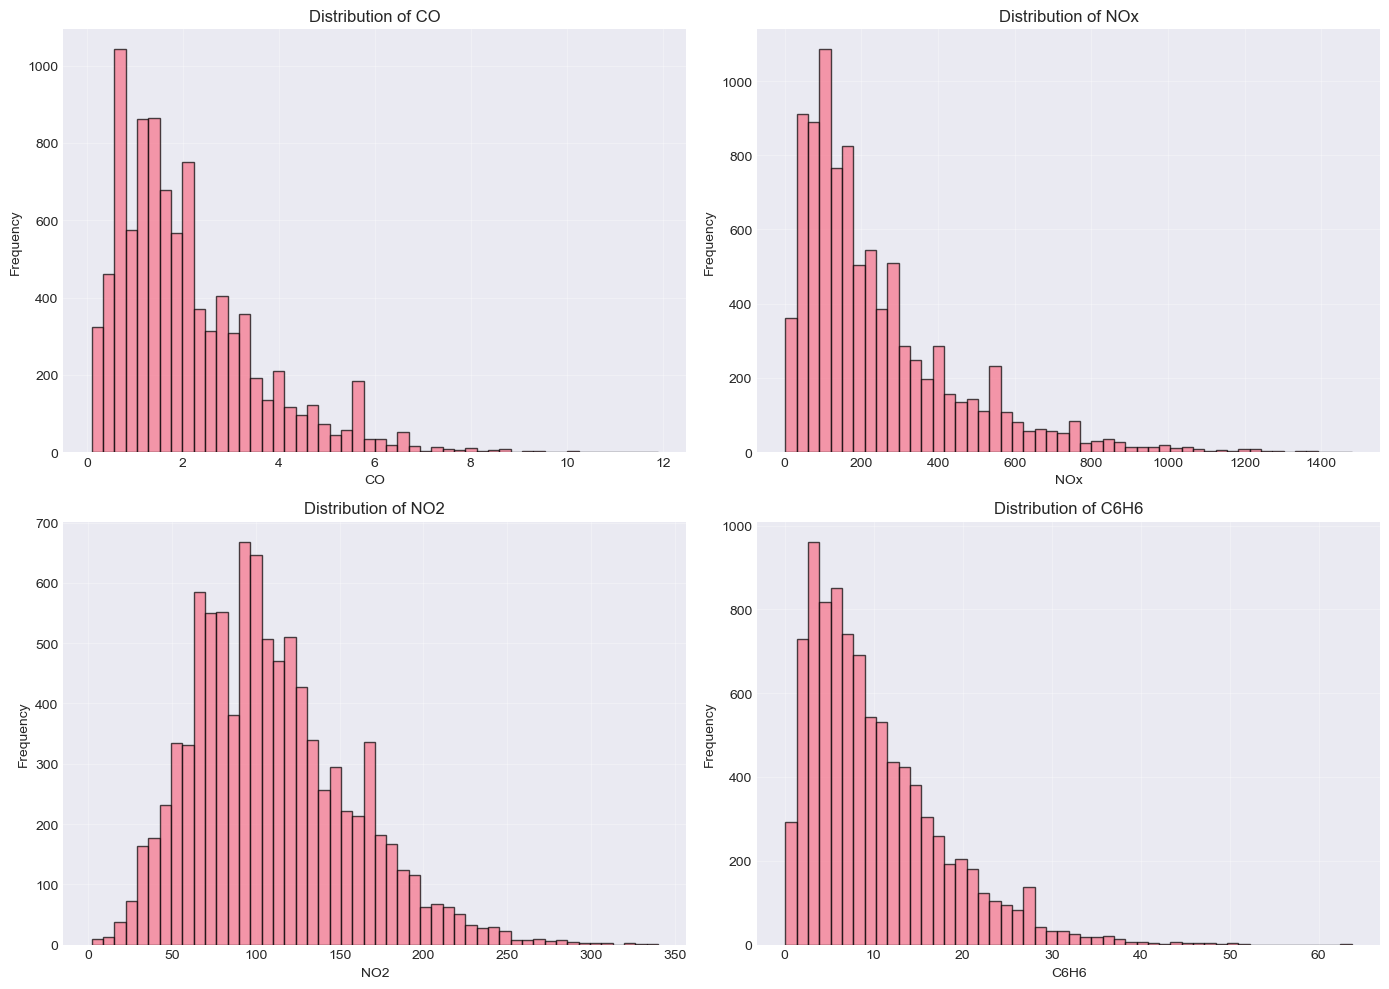

Pollution score statistics:
  Mean: 0.000
  Std: 0.881
  Min: -1.444
  Max: 5.018


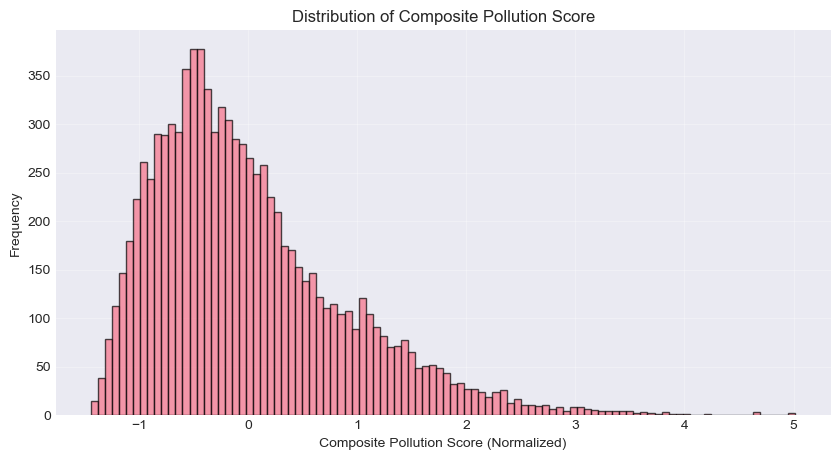

Number of observation bins: 3

Observation distribution:
Low       3109
Medium    3108
High      3109
Name: count, dtype: int64

Proportions:


TypeError: Categorical.value_counts() got an unexpected keyword argument 'normalize'

In [3]:
# %% [markdown]
# # Hidden Markov Model Analysis of Air Quality Data
# 
# This notebook investigates how air pollution evolves over time by identifying 
# hidden pollution regimes using a Gaussian Hidden Markov Model.

# %% [markdown]
# ## 1. Import Libraries and Setup

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Import the HMM class (assumes hmm.py is in the same directory)
from hmm import HiddenMarkovModel

# Set style and random seed
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

print("✓ Libraries imported successfully")

# %% [markdown]
# ## 2. Load and Explore Cleaned Data

# %%
# Load cleaned dataset
df = pd.read_csv('AirQualityUCI_cleaned_with_time_features.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['DateTime'].min()} to {df['DateTime'].max()}")
print(f"\nColumns: {df.columns.tolist()}")

# %%
# Display first few rows
df.head(10)

# %%
# Check data types
df.dtypes

# %%
# Summary statistics
df.describe()

# %% [markdown]
# ## 3. Select and Preprocess Features

# %%
# Select key pollutants for HMM
feature_columns = ['CO', 'NOx', 'NO2', 'C6H6']  # Main pollutants
print(f"Selected features: {feature_columns}")

# Check missing values
print(f"\nMissing values before handling:")
for col in feature_columns:
    missing = df[col].isna().sum()
    pct = missing/len(df)*100
    print(f"  {col}: {missing} ({pct:.1f}%)")

# %%
# Handle missing values - forward fill then backward fill
df_features = df[feature_columns].copy()
df_features = df_features.ffill().bfill()

# Remove any remaining rows with NaN
valid_idx = df_features.notna().all(axis=1)
df_features = df_features[valid_idx]
df_clean = df[valid_idx].copy()

print(f"Rows after handling missing values: {len(df_features)}")
print(f"Rows removed: {len(df) - len(df_features)}")

# %%
# Visualize raw pollutant distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(feature_columns):
    axes[idx].hist(df_features[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 4. Discretize Continuous Observations

# %%
# Normalize features first
scaler = StandardScaler()
features_normalized = scaler.fit_transform(df_features)

# Create a composite pollution score (average of normalized values)
pollution_score = features_normalized.mean(axis=1)

print(f"Pollution score statistics:")
print(f"  Mean: {pollution_score.mean():.3f}")
print(f"  Std: {pollution_score.std():.3f}")
print(f"  Min: {pollution_score.min():.3f}")
print(f"  Max: {pollution_score.max():.3f}")

# %%
# Visualize pollution score distribution
plt.figure(figsize=(10, 5))
plt.hist(pollution_score, bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('Composite Pollution Score (Normalized)')
plt.ylabel('Frequency')
plt.title('Distribution of Composite Pollution Score')
plt.grid(True, alpha=0.3)
plt.show()

# %%
# Discretize into bins (Low, Medium, High pollution levels)
n_bins = 3
bins = pd.qcut(pollution_score, q=n_bins, labels=['Low', 'Medium', 'High'])
observations = bins.to_numpy()  # Use .to_numpy() instead of .values

print(f"Number of observation bins: {n_bins}")
print(f"\nObservation distribution:")
print(bins.value_counts().sort_index())
print(f"\nProportions:")
print(bins.value_counts(normalize=True).sort_index())

# %% [markdown]
# ## 5. Initialize HMM Parameters

# %%
# Define hidden states (pollution regimes)
n_states = 3
states = ['Clean', 'Moderate', 'Polluted']
obs_symbols = ['Low', 'Medium', 'High']

print(f"Number of hidden states: {n_states}")
print(f"Hidden states: {states}")
print(f"Observation symbols: {obs_symbols}")

# %%
# Initialize transition matrix (slight preference to stay in same state)
transition_prob = np.array([
    [0.7, 0.2, 0.1],  # From Clean
    [0.2, 0.6, 0.2],  # From Moderate
    [0.1, 0.2, 0.7]   # From Polluted
])

# Initialize emission matrix (states tend to emit similar observations)
emission_prob = np.array([
    [0.7, 0.2, 0.1],  # Clean state
    [0.2, 0.6, 0.2],  # Moderate state
    [0.1, 0.2, 0.7]   # Polluted state
])

# Initial state distribution (uniform)
init_prob = np.array([1/3, 1/3, 1/3])

print("\nInitial Transition Matrix:")
print(pd.DataFrame(transition_prob, index=states, columns=states))

print("\nInitial Emission Matrix:")
print(pd.DataFrame(emission_prob, index=states, columns=obs_symbols))

print("\nInitial State Distribution:")
print(pd.Series(init_prob, index=states))

# %%
# Create HMM
hmm = HiddenMarkovModel(
    states=states,
    observations=obs_symbols,
    transition_prob=transition_prob,
    emission_prob=emission_prob,
    init_prob=init_prob
)

print("✓ HMM initialized successfully")

# %% [markdown]
# ## 6. Train HMM Using Baum-Welch Algorithm

# %%
# Use a subset for training (first 2000 observations for faster training)
train_size = min(2000, len(observations))
obs_train = observations[:train_size]

print(f"Training on {train_size} observations...")

# Calculate initial likelihood
initial_likelihood = hmm.likelihood(obs_train)
print(f"Initial log-likelihood: {np.log(initial_likelihood):.2f}")

# %%
# Train for multiple iterations
n_iterations = 10
print(f"Training for {n_iterations} iterations...")

likelihoods = [np.log(initial_likelihood)]

for i in range(n_iterations):
    hmm.learn(obs_train, iterations=1)
    likelihood = hmm.likelihood(obs_train)
    log_likelihood = np.log(likelihood)
    likelihoods.append(log_likelihood)
    print(f"  Iteration {i+1}: log-likelihood = {log_likelihood:.2f}")

final_likelihood = hmm.likelihood(obs_train)
print(f"\nFinal log-likelihood: {np.log(final_likelihood):.2f}")
print(f"Improvement: {np.log(final_likelihood) - np.log(initial_likelihood):.2f}")

# %%
# Plot likelihood convergence
plt.figure(figsize=(10, 5))
plt.plot(range(len(likelihoods)), likelihoods, marker='o', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.title('Baum-Welch Training Convergence')
plt.grid(True, alpha=0.3)
plt.show()

# %%
print("Learned Transition Matrix:")
transition_df = pd.DataFrame(hmm.A, index=states, columns=states)
display(transition_df.round(3))

print("\nLearned Emission Matrix:")
emission_df = pd.DataFrame(hmm.B, index=states, columns=obs_symbols)
display(emission_df.round(3))

# %% [markdown]
# ## 7. Decode Hidden States Using Viterbi Algorithm

# %%
# Decode the full sequence
print("Decoding hidden states for all observations...")
hidden_states, max_prob = hmm.decode(observations)

print(f"✓ Decoded {len(observations)} observations")
print(f"Max path probability: {max_prob:.2e}")

# Add to dataframe
df_clean['Observation'] = observations
df_clean['Hidden_State'] = hidden_states

# %%
print("Hidden state distribution:")
state_counts = df_clean['Hidden_State'].value_counts()
display(state_counts)
print("\nProportions:")
display(state_counts / len(df_clean))

# %%
# Show sample of decoded states
df_clean[['DateTime', 'CO', 'NOx', 'NO2', 'C6H6', 'Observation', 'Hidden_State']].head(20)

# %% [markdown]
# ## 8. Analyze Temporal Patterns

# %%
# Regime by hour of day
regime_by_hour = df_clean.groupby('Hour')['Hidden_State'].value_counts(normalize=True).unstack(fill_value=0)
print("Regime Distribution by Hour of Day:")
display(regime_by_hour.round(3))

# %%
# Regime by day of week
regime_by_dow = df_clean.groupby('DayOfWeek')['Hidden_State'].value_counts(normalize=True).unstack(fill_value=0)
print("Regime Distribution by Day of Week (0=Monday, 6=Sunday):")
display(regime_by_dow.round(3))

# %%
# Regime by month
regime_by_month = df_clean.groupby('Month')['Hidden_State'].value_counts(normalize=True).unstack(fill_value=0)
print("Regime Distribution by Month:")
display(regime_by_month.round(3))

# %% [markdown]
# ## 9. Visualizations

# %%
# Plot 1: Time series of hidden states (first 500 points)
sample_size = min(500, len(df_clean))
df_sample = df_clean.iloc[:sample_size]

plt.figure(figsize=(15, 4))
state_numeric = pd.Categorical(df_sample['Hidden_State'], categories=states).codes
plt.plot(df_sample['DateTime'], state_numeric, linewidth=0.8, alpha=0.7)
plt.yticks(range(len(states)), states)
plt.xlabel('DateTime')
plt.ylabel('Hidden State')
plt.title(f'Hidden State Sequence (First {sample_size} Observations)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# Plot 2: State distribution
plt.figure(figsize=(8, 5))
state_counts = df_clean['Hidden_State'].value_counts()
colors = ['green', 'orange', 'red']
plt.bar(state_counts.index, state_counts.values, color=colors)
plt.xlabel('Hidden State')
plt.ylabel('Count')
plt.title('Distribution of Hidden States')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# Plot 3: Regime by hour
plt.figure(figsize=(12, 5))
regime_by_hour.plot(kind='bar', stacked=True, color=['green', 'orange', 'red'])
plt.xlabel('Hour of Day')
plt.ylabel('Proportion')
plt.title('Pollution Regime by Hour of Day')
plt.legend(title='State', bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# Plot 4: Regime by day of week
plt.figure(figsize=(10, 5))
regime_by_dow.plot(kind='bar', stacked=True, color=['green', 'orange', 'red'])
plt.xlabel('Day of Week')
plt.ylabel('Proportion')
plt.title('Pollution Regime by Day of Week')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45)
plt.legend(title='State', bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# Plot 5: Regime by month
plt.figure(figsize=(10, 5))
regime_by_month.plot(kind='bar', stacked=True, color=['green', 'orange', 'red'])
plt.xlabel('Month')
plt.ylabel('Proportion')
plt.title('Pollution Regime by Month')
plt.legend(title='State', bbox_to_anchor=(1.05, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# Plot 6: Transition matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(hmm.A, annot=True, fmt='.3f', cmap='YlOrRd', 
            xticklabels=states, yticklabels=states, 
            cbar_kws={'label': 'Probability'})
plt.xlabel('To State')
plt.ylabel('From State')
plt.title('Learned Transition Matrix')
plt.tight_layout()
plt.show()

# %%
# Combined visualization
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Plot 1: Time series
ax = axes[0, 0]
sample_size = min(500, len(df_clean))
df_sample = df_clean.iloc[:sample_size]
state_numeric = pd.Categorical(df_sample['Hidden_State'], categories=states).codes
ax.plot(df_sample['DateTime'], state_numeric, linewidth=0.5)
ax.set_yticks(range(len(states)))
ax.set_yticklabels(states)
ax.set_xlabel('DateTime')
ax.set_ylabel('Hidden State')
ax.set_title(f'Hidden State Sequence (First {sample_size} Observations)')
ax.grid(True, alpha=0.3)

# Plot 2: State distribution
ax = axes[0, 1]
state_counts = df_clean['Hidden_State'].value_counts()
ax.bar(state_counts.index, state_counts.values, color=['green', 'orange', 'red'])
ax.set_xlabel('Hidden State')
ax.set_ylabel('Count')
ax.set_title('Distribution of Hidden States')
ax.grid(True, alpha=0.3)

# Plot 3: Regime by hour
ax = axes[1, 0]
regime_by_hour.plot(kind='bar', stacked=True, ax=ax, color=['green', 'orange', 'red'])
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Proportion')
ax.set_title('Pollution Regime by Hour of Day')
ax.legend(title='State')
ax.grid(True, alpha=0.3)

# Plot 4: Regime by day of week
ax = axes[1, 1]
regime_by_dow.plot(kind='bar', stacked=True, ax=ax, color=['green', 'orange', 'red'])
ax.set_xlabel('Day of Week')
ax.set_ylabel('Proportion')
ax.set_title('Pollution Regime by Day of Week')
ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=45)
ax.legend(title='State')
ax.grid(True, alpha=0.3)

# Plot 5: Regime by month
ax = axes[2, 0]
regime_by_month.plot(kind='bar', stacked=True, ax=ax, color=['green', 'orange', 'red'])
ax.set_xlabel('Month')
ax.set_ylabel('Proportion')
ax.set_title('Pollution Regime by Month')
ax.legend(title='State')
ax.grid(True, alpha=0.3)

# Plot 6: Transition matrix heatmap
ax = axes[2, 1]
sns.heatmap(hmm.A, annot=True, fmt='.3f', cmap='YlOrRd', 
            xticklabels=states, yticklabels=states, ax=ax, 
            cbar_kws={'label': 'Probability'})
ax.set_xlabel('To State')
ax.set_ylabel('From State')
ax.set_title('Learned Transition Matrix')

plt.tight_layout()
plt.savefig('hmm_air_quality_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Visualizations saved to 'hmm_air_quality_analysis.png'")
plt.show()

# %% [markdown]
# ## 10. Save Results

# %%
# Save dataframe with decoded states
df_clean.to_csv('AirQualityUCI_with_states.csv', index=False)
print("✓ Results saved to 'AirQualityUCI_with_states.csv'")

# %%
# Save model parameters
model_params = {
    'Transition Matrix': pd.DataFrame(hmm.A, index=states, columns=states),
    'Emission Matrix': pd.DataFrame(hmm.B, index=states, columns=obs_symbols),
    'Initial Probabilities': pd.Series(hmm.pi, index=states)
}

with pd.ExcelWriter('hmm_parameters.xlsx') as writer:
    for name, data in model_params.items():
        data.to_excel(writer, sheet_name=name)
print("✓ Model parameters saved to 'hmm_parameters.xlsx'")

# %% [markdown]
# ## 11. Summary and Insights

# %%
print("="*70)
print("ANALYSIS SUMMARY")
print("="*70)
print(f"\n✓ Trained HMM with {n_states} hidden states")
print(f"✓ Decoded {len(observations)} observations")
print(f"✓ Log-likelihood improvement: {np.log(final_likelihood) - np.log(initial_likelihood):.2f}")
print(f"\nHidden State Distribution:")
for state in states:
    count = (df_clean['Hidden_State'] == state).sum()
    pct = count / len(df_clean) * 100
    print(f"  {state}: {count} ({pct:.1f}%)")
print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)

# %% [markdown]
# ## 12. Variables for Notebook Checker

# %%
# Create variables that match the expected names from the checker notebook
state_space = states
observation_space = obs_symbols
initial_probabilities = hmm.pi
transition_probabilities = hmm.A
emission_probabilities = hmm.B

# The trained HMM object
# hmm is already defined above

# The observation sequence used
observation_sequence = obs_train

# Results from decoding
path, prob = hmm.decode(observation_sequence)

print("Variables created for checker:")
print(f"  - state_space: {state_space}")
print(f"  - observation_space: {observation_space}")
print(f"  - initial_probabilities shape: {initial_probabilities.shape}")
print(f"  - transition_probabilities shape: {transition_probabilities.shape}")
print(f"  - emission_probabilities shape: {emission_probabilities.shape}")
print(f"  - hmm: {type(hmm)}")
print(f"  - observation_sequence length: {len(observation_sequence)}")
print(f"  - path length: {len(path)}")
print(f"  - prob: {prob:.2e}")